For questions 1 to 5 

- Load the breast cancer dataset from scikit-learn; you can do this by running load_breast_cancer() from sklearn.datasets 
- The target variable here is whether the patient was identified to have breast cancer or not, a flowering plant (use the .target attribute of your dataset to acquire this) 
- You can acquire the predictor data using the .data attribute on your datset
- Using sklearn.model_selection.train_test_split(), please split the dataset as follows
    - Use a 70:30 train:test split 
    - Set random_state = 9001 so that the results you obtain can be compared to ours 
    - Stratify the target feature labels so we have an equal distribution in both test and training sets 
- Build a decision tree on this dataset using DecisionTreeClassifier() from sklearn.tree to perform the classification 
    - Set max_depth = 3 to fix the depth of the decision tree 
    - Set random_state = 9001 so that the results you obtain can be compared to ours 
    - Fit the tree on the training set 
- Make predictions using the .predict() method on the test set 
- Print the confusion matrix to understand the performance better 
- Obtain a classification report containing metrics such as accuracy, precision, and recall on this data; you can use classification_report() from sklearn.metrics to achieve this 
- You can plot the decision tree using the plot_tree() function from the tree module of sklearn

For questions 6, 7 
- These are theoretical questions. Based on your understanding of the topics, answer these questions. 

 

In [ ]:
# 1. Load dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
data.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
# 2. Get predictors and target
import pandas as pd
# X = data.data
# y = data.target
# convering to Pandas for better debugging
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [6]:
X.head()
y.head()
data.target_names
X.shape

(569, 30)

In [26]:
# 3. Train-test split with stratification
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=9001,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((398, 30), (171, 30), (398,), (171,))

In [27]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree
# 4. Build decision tree
dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=9001
)

In [28]:
# 5. Fit on training data
dt.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",9001
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [31]:
# 6. Predict on test data
y_test_pred = dt.predict(X_test)
y_train_pred = dt.predict(X_train)

In [35]:
# 7. Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
print("Confusion Matrix:")
print(cm)
# [[TN FP]
#  [FN TP]]

Confusion Matrix:
[[ 58   6]
 [  5 102]]


In [33]:
# 8. Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_test_pred, target_names=data.target_names))


Classification Report:
              precision    recall  f1-score   support

   malignant       0.92      0.91      0.91        64
      benign       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171



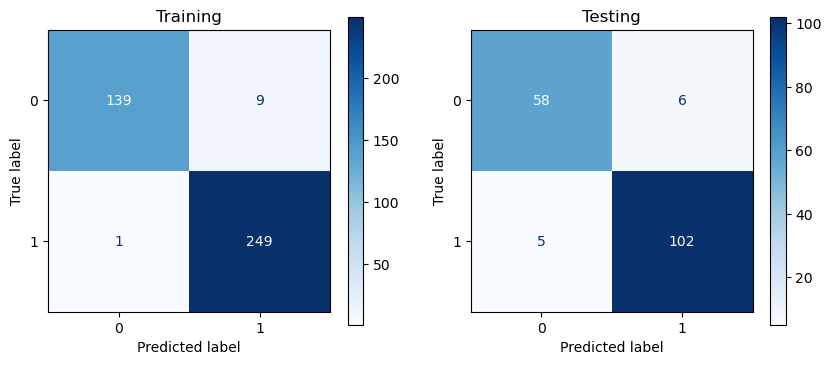

In [29]:
# -------- Plot confusion matrices --------
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_train,
    y_train,
    cmap=plt.cm.Blues,
    ax=ax[0]
)

ConfusionMatrixDisplay.from_estimator(
    dt,
    X_test,
    y_test,
    cmap=plt.cm.Blues,
    ax=ax[1]
)

ax[0].set_title("Training")
ax[1].set_title("Testing")

plt.show()
# In cancer detection, False Negatives are dangerous => Actual cancer → predicted benign
# In test  model missed 5 cancer cases.
# This is why in medical ML we often prioritize recall for the cancer class.


| Case | Count | Meaning                       |
| ---- | ----- | ----------------------------- |
| TN   | 139   | malignant correctly predicted |
| FP   | 9     | malignant predicted as benign |
| FN   | 1     | benign predicted as malignant |
| TP   | 249   | benign correctly predicted    |


In [32]:
# Print the accuracy scores
from sklearn.metrics import accuracy_score
print(f'Accuracy score on the training dataset: {round(accuracy_score(y_train_pred, y_train), 3)}')
print(f'Accuracy score on the testing dataset: {round(accuracy_score(y_test_pred, y_test), 3)}')

Accuracy score on the training dataset: 0.975
Accuracy score on the testing dataset: 0.936


Number of leaves = 8
Tree depth = 3


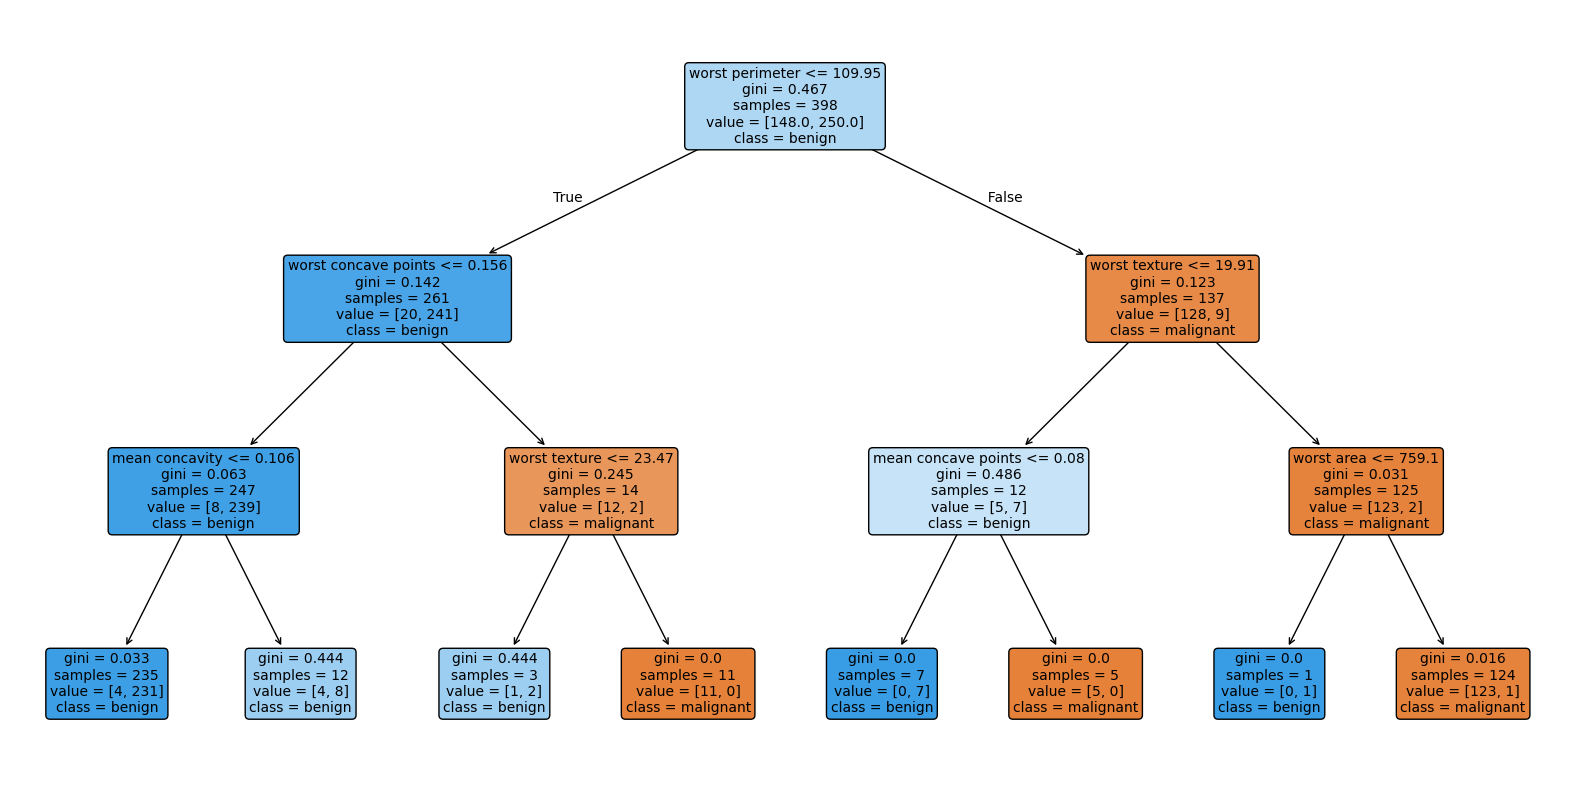

In [34]:
# 9. Plot the decision tree
from sklearn.tree import DecisionTreeClassifier, plot_tree

plt.figure(figsize=(20, 10))
plot_tree(
    dt,
    feature_names=data.feature_names,
    class_names=data.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
# Print the number of leaves and the depth of the tree
print('Number of leaves =', dt.get_n_leaves())
print('Tree depth =', dt.get_depth())
plt.show()